In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('DataSet/dataset_countries.csv')

df = df[df['year'] >= 1950].copy()

bins = list(range(1950, 2031, 10))
labels = [f'{b}-{b+9}' for b in bins[:-1]]
df['period'] = pd.cut(df['year'], bins=bins, labels=labels, right=False)

print(f'Shape: {df.shape}')
print(f'Períodos: {df["period"].cat.categories.tolist()}')
df.head()

Shape: (17390, 8)
Períodos: ['1950-1959', '1960-1969', '1970-1979', '1980-1989', '1990-1999', '2000-2009', '2010-2019', '2020-2029']


,entity,code,year,child_mortality_rate,fertility_rate_hist,continent,sub_region,period
0,Afghanistan,AFG,1950,37.13,7.248,Asia,Southern Asia,1950-1959
1,Afghanistan,AFG,1951,37.13,7.260,Asia,Southern Asia,1950-1959
2,Afghanistan,AFG,1952,37.13,7.260,Asia,Southern Asia,1950-1959
3,Afghanistan,AFG,1953,37.13,7.266,Asia,Southern Asia,1950-1959
4,Afghanistan,AFG,1954,37.13,7.254,Asia,Southern Asia,1950-1959


In [8]:
#tabela agregada por país e período
country_period = (
    df.groupby(['entity', 'code', 'continent', 'period'], observed=True)
    .agg(
        avg_mortality=('child_mortality_rate', 'mean'),
        avg_fertility=('fertility_rate_hist', 'mean')
    )
    .reset_index()
)

print(f'Shape: {country_period.shape}')
country_period.sample(10, random_state=42)

Shape: (1880, 6)


,entity,code,continent,period,avg_mortality,avg_fertility
1112,Montenegro,MNE,Europe,1950-1959,2.72000,4.2061
710,Guinea,GIN,Africa,2010-2019,11.42200,5.0180
1571,South Africa,ZAF,Africa,1980-1989,7.51200,4.4799
808,Isle of Man,IMN,Europe,1950-1959,7.30375,2.2253
270,Burundi,BDI,Africa,2010-2019,7.12300,5.7456
1285,Palau,PLW,Oceania,2000-2009,2.27500,1.9426
888,Kuwait,KWT,Asia,1950-1959,15.22000,7.1486
1244,North Macedonia,MKD,Europe,1990-1999,2.65000,2.1117
1814,Vanuatu,VUT,Oceania,2010-2019,1.91100,3.9682
1310,Papua New Guinea,PNG,Oceania,2010-2019,5.23100,3.5943


In [9]:
#tabela agregada por continente e período
continent_period = (
    df.groupby(['continent', 'period'], observed=True)
    .agg(
        avg_mortality=('child_mortality_rate', 'mean'),
        avg_fertility=('fertility_rate_hist', 'mean')
    )
    .reset_index()
)

continent_period

,continent,period,avg_mortality,avg_fertility
0,Africa,1950-1959,25.195828,6.467372
1,Africa,1960-1969,22.295483,6.637993
2,Africa,1970-1979,19.111707,6.568424
3,Africa,1980-1989,15.856500,6.193843
4,Africa,1990-1999,13.622793,5.445447
5,Africa,2000-2009,10.144483,4.831760
6,Africa,2010-2019,7.149810,4.329757
7,Africa,2020-2029,5.863922,3.857716
8,Americas,1950-1959,11.732364,5.544880
9,Americas,1960-1969,9.485400,5.255178


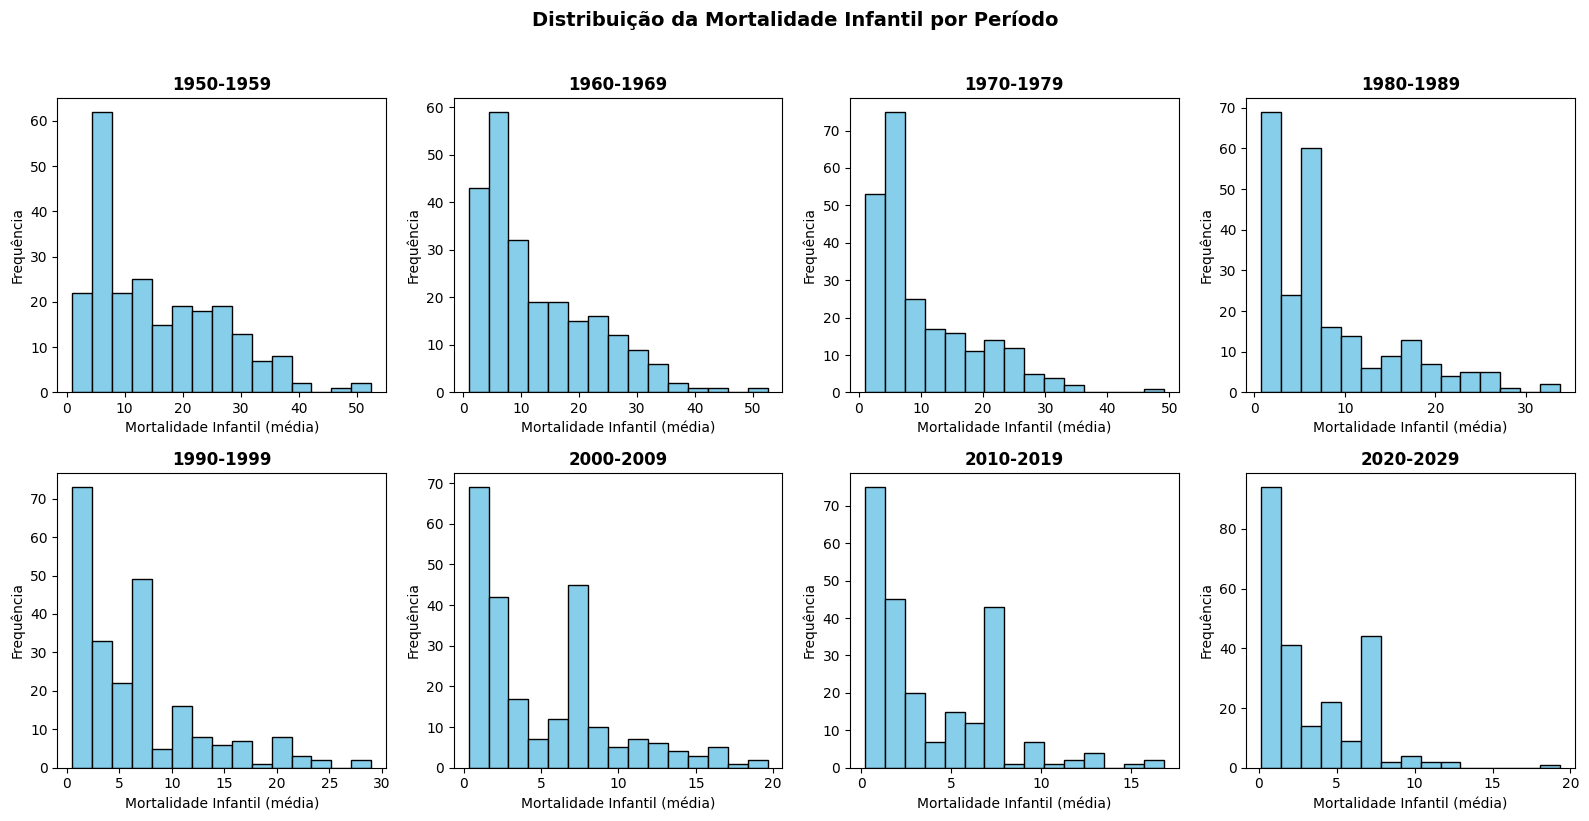

In [10]:
#histogramas de mortalidade infantil por período
periods = country_period['period'].cat.categories.tolist()
n_periods = len(periods)
ncols = 4
nrows = int(np.ceil(n_periods / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, period in enumerate(periods):
    ax = axes[i]
    data = country_period[country_period['period'] == period]['avg_mortality'].dropna()
    ax.hist(data, bins=15, color='skyblue', edgecolor='black')
    ax.set_title(period, fontsize=12, fontweight='bold')
    ax.set_xlabel('Mortalidade Infantil (média)')
    ax.set_ylabel('Frequência')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuição da Mortalidade Infantil por Período', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

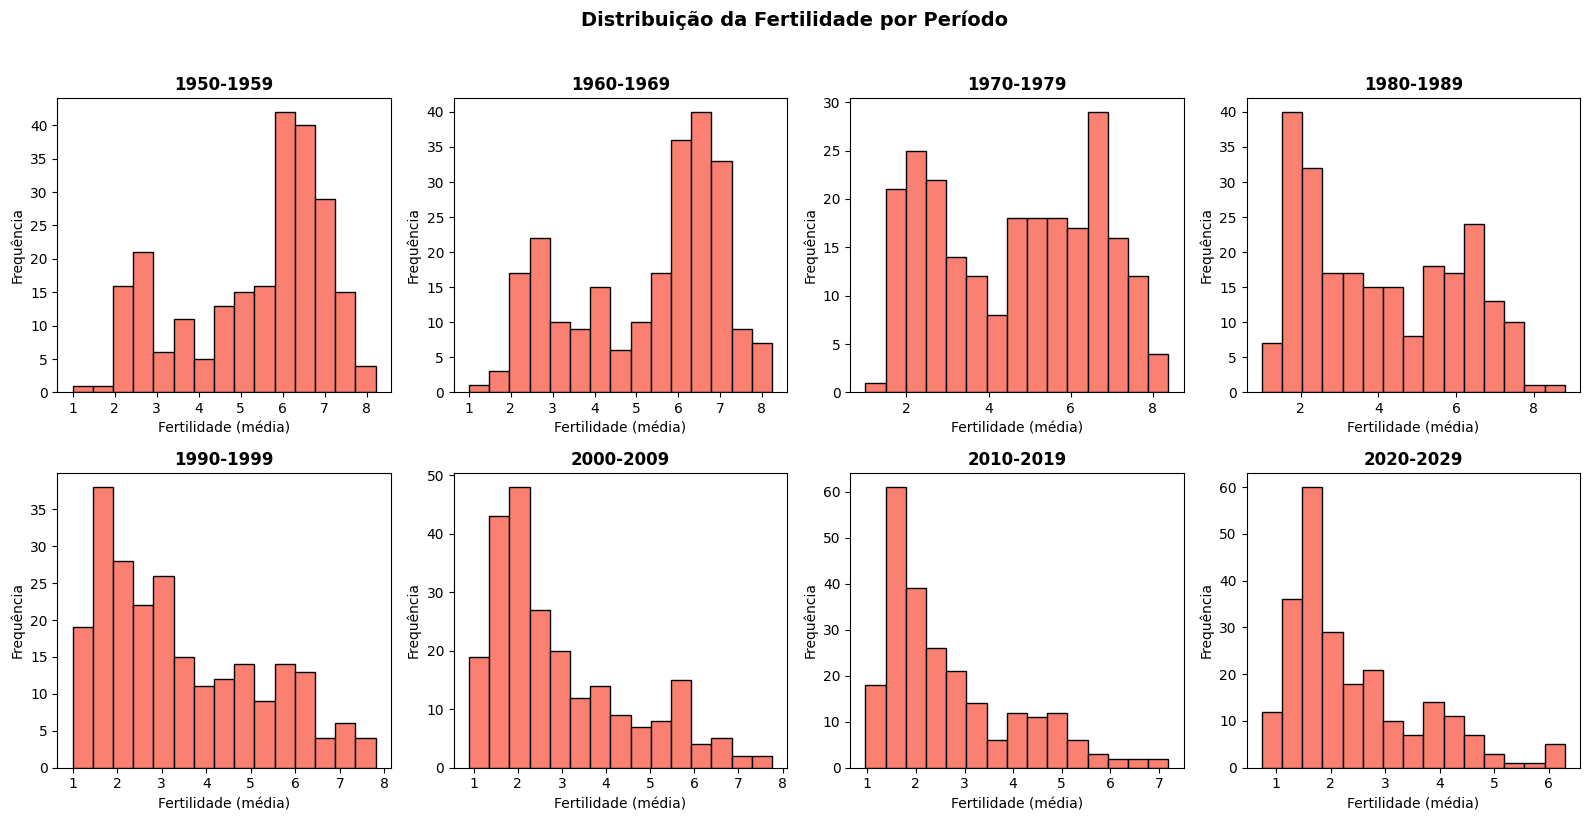

In [11]:
#histogramas de fertilidade por período
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, period in enumerate(periods):
    ax = axes[i]
    data = country_period[country_period['period'] == period]['avg_fertility'].dropna()
    ax.hist(data, bins=15, color='salmon', edgecolor='black')
    ax.set_title(period, fontsize=12, fontweight='bold')
    ax.set_xlabel('Fertilidade (média)')
    ax.set_ylabel('Frequência')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuição da Fertilidade por Período', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

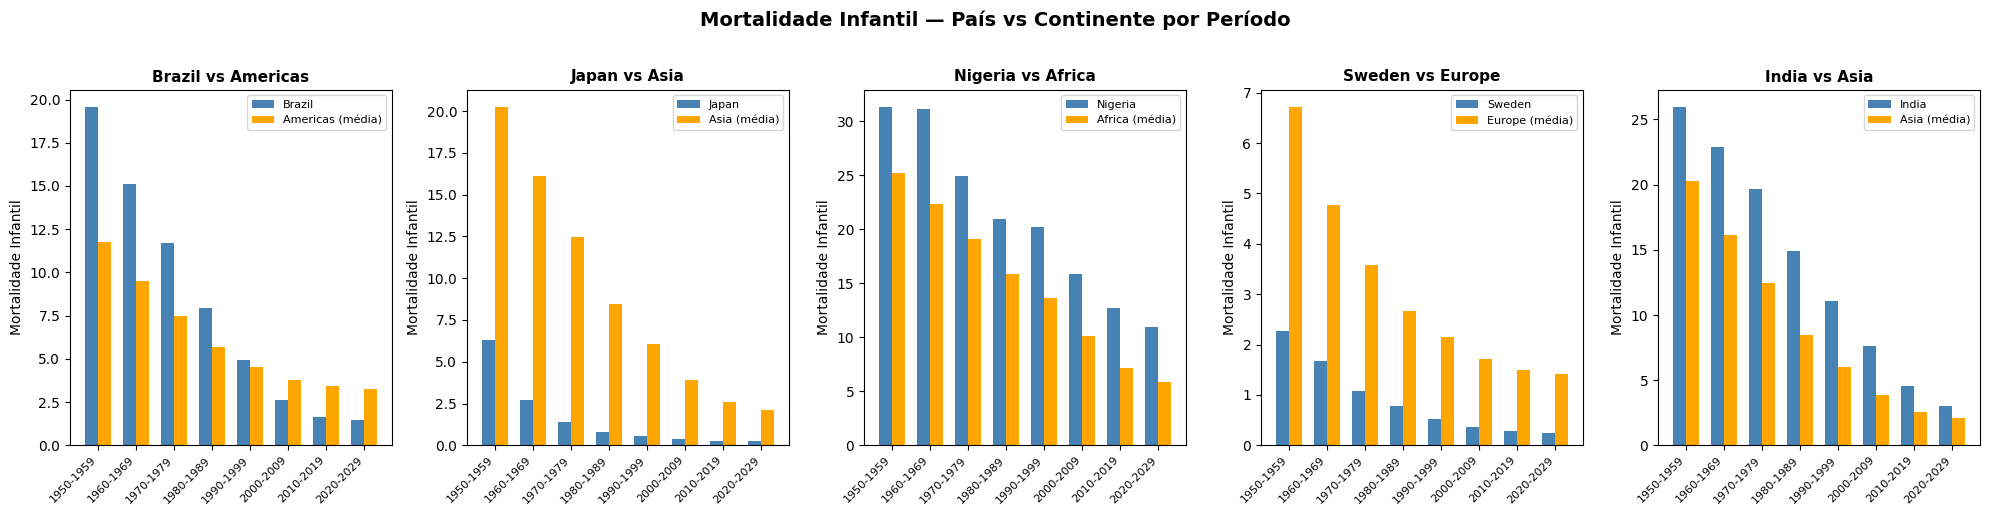

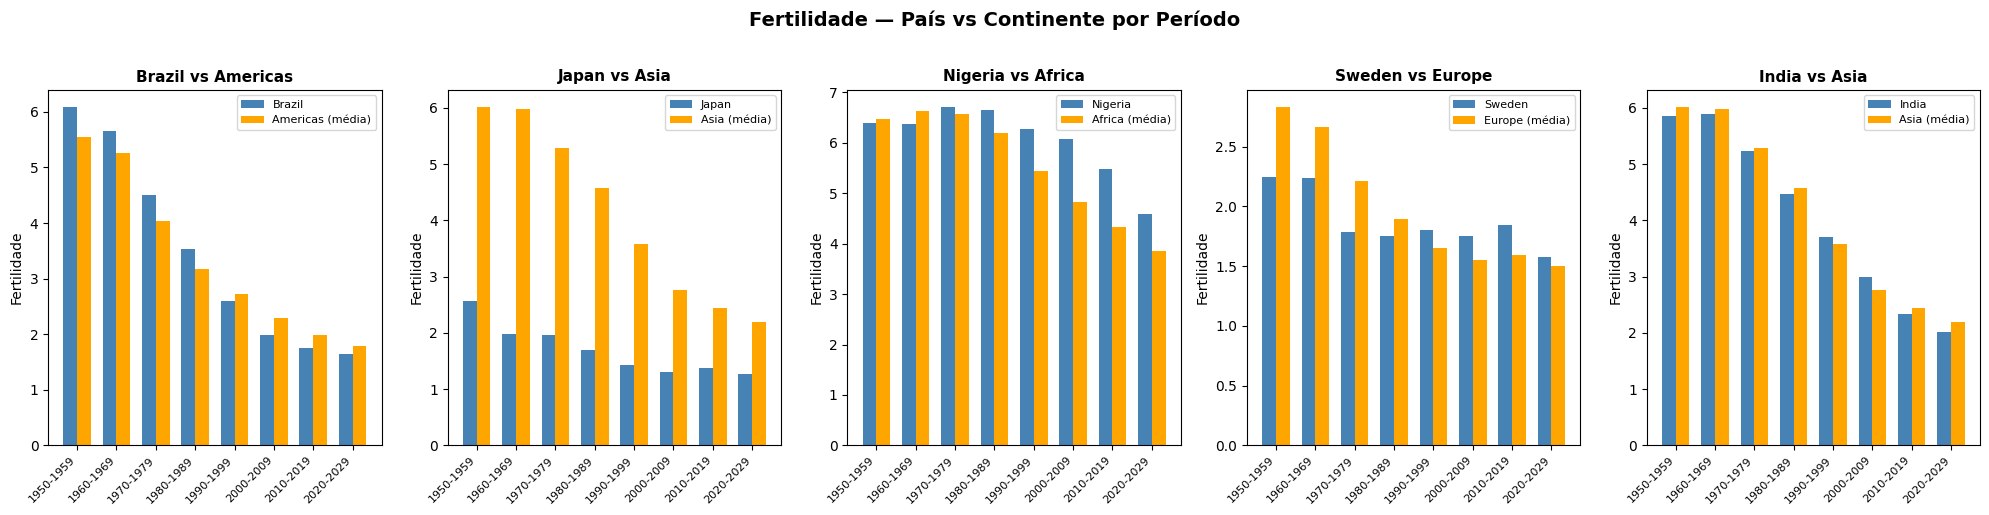

In [12]:
#comparação: pais x media continente
focus_countries = ['Brazil', 'Japan', 'Nigeria', 'Sweden', 'India']

def plot_comparison(metric, metric_label):
    fig, axes = plt.subplots(1, len(focus_countries), figsize=(4 * len(focus_countries), 5))

    for idx, country in enumerate(focus_countries):
        ax = axes[idx]
        country_data = country_period[country_period['entity'] == country].sort_values('period')
        continent_name = country_data['continent'].iloc[0]
        continent_data = continent_period[continent_period['continent'] == continent_name].sort_values('period')

        common_periods = sorted(
            set(country_data['period']) & set(continent_data['period']),
            key=lambda x: periods.index(x)
        )

        country_vals = country_data[country_data['period'].isin(common_periods)].set_index('period').loc[common_periods, metric].values
        continent_vals = continent_data[continent_data['period'].isin(common_periods)].set_index('period').loc[common_periods, metric].values

        x = np.arange(len(common_periods))
        width = 0.35

        ax.bar(x - width/2, country_vals, width, label=country, color='steelblue')
        ax.bar(x + width/2, continent_vals, width, label=f'{continent_name} (média)', color='orange')

        ax.set_title(f'{country} vs {continent_name}', fontsize=11, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([str(p) for p in common_periods], rotation=45, ha='right', fontsize=8)
        ax.set_ylabel(metric_label)
        ax.legend(fontsize=8)

    fig.suptitle(f'{metric_label} — País vs Continente por Período', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_comparison('avg_mortality', 'Mortalidade Infantil')
plot_comparison('avg_fertility', 'Fertilidade')